# Laboratorio 6 – K-Nearest Neighbors (KNN)

## 0. Configuración — Pipeline de Labs 4 y 5

In [1]:
import pyreadr, pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import time, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score)
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

In [2]:
result  = pyreadr.read_r('listings.Rdata')
df_raw  = result[list(result.keys())[0]].copy()

df = df_raw.copy()
if df['price'].dtype == object:
    df['price'] = (df['price'].str.replace(r'[\$,]','',regex=True)
                   .str.strip().replace('',np.nan).astype(float))
q_high = df['price'].quantile(0.99)
df = df[(df['price'] > 0) & (df['price'] <= q_high)].copy()

cols_drop = ['id','listing_url','scrape_id','last_scraped','source','name',
    'description','neighborhood_overview','picture_url','host_url',
    'host_thumbnail_url','host_picture_url','host_about','host_verifications',
    'amenities','calendar_updated','calendar_last_scraped','license',
    'bathrooms_text','minimum_minimum_nights','maximum_minimum_nights',
    'minimum_maximum_nights','maximum_maximum_nights',
    'minimum_nights_avg_ntm','maximum_nights_avg_ntm']
df = df.drop(columns=[c for c in cols_drop if c in df.columns])
null_pct = df.isnull().mean()
df = df.drop(columns=null_pct[null_pct > 0.60].index.tolist())

if 'host_since' in df.columns:
    df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
    df['host_years'] = ((pd.Timestamp('2024-01-01') - df['host_since']).dt.days/365).round(1)
    df = df.drop(columns=['host_since'])
df = df.drop(columns=[c for c in ['first_review','last_review'] if c in df.columns], errors='ignore')

for col in ['host_is_superhost','host_has_profile_pic','host_identity_verified',
            'has_availability','instant_bookable']:
    if col in df.columns:
        df[col] = df[col].map({'t':1,'f':0,True:1,False:0})
for col in ['host_response_rate','host_acceptance_rate']:
    if col in df.columns:
        df[col] = df[col].str.replace('%','',regex=False).str.strip().astype(float, errors='ignore')

TARGET = 'price'
num_features = [c for c in df.select_dtypes(include='number').columns if c != TARGET]
cat_features = [c for c in ['room_type','property_type','neighbourhood_cleansed',
                              'host_response_time'] if c in df.columns]
for col in cat_features:
    freq = df[col].value_counts(normalize=True)
    df[col] = df[col].replace(freq[freq < 0.01].index, 'Otro')
df_encoded = pd.get_dummies(df[num_features+cat_features+[TARGET]],
                             columns=cat_features, drop_first=True, dtype=int)
for col in df_encoded.columns:
    if df_encoded[col].isnull().any():
        df_encoded[col].fillna(df_encoded[col].median(), inplace=True)

p33 = df_encoded[TARGET].quantile(0.33)
p67 = df_encoded[TARGET].quantile(0.67)
df_encoded['price_category'] = df_encoded[TARGET].apply(
    lambda p: 'Económico' if p<=p33 else ('Intermedio' if p<=p67 else 'Caro'))

feature_cols = [c for c in df_encoded.columns if c not in [TARGET,'price_category']]
X = df_encoded[feature_cols]; y = df_encoded[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

le = LabelEncoder()
y_clf = le.fit_transform(df_encoded['price_category'])
X_clf = df_encoded[feature_cols]
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.20, random_state=42, stratify=y_clf)

print(f"Dataset: {df_encoded.shape[0]:,} filas × {len(feature_cols)} features")
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"price_category — P33=${p33:.0f}  P67=${p67:.0f}")
print(f"Clases: {dict(zip(le.classes_, le.transform(le.classes_)))}")
print("Pipeline reproducido — idéntico a Lab 4 y Lab 5.")


Dataset: 75,531 filas × 73 features
Train: 60,424  |  Test: 15,107
price_category — P33=$140  P67=$267
Clases: {'Caro': 0, 'Económico': 1, 'Intermedio': 2}
Pipeline reproducido — idéntico a Lab 4 y Lab 5.


In [3]:
# KNN calcula distancias euclidianas entre puntos. Sin escalar, variables con
# rangos grandes (ej: availability_365: 0-365) dominarían la distancia respecto
# a variables con rangos pequeños (ej: review_scores_rating: 3-5), haciendo que
# esas variables aporten casi cero información al cálculo de vecinos.
# Se ajusta StandardScaler SOLO sobre X_train para evitar data leakage.

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit + transform sobre train
X_test_sc  = scaler.transform(X_test)        # solo transform sobre test

X_train_c_sc = scaler.fit_transform(X_train_c)
X_test_c_sc  = scaler.transform(X_test_c)

print(f"Media X_train_sc (primeras 3 cols): {X_train_sc[:, :3].mean(axis=0).round(4)}")
print(f"Std  X_train_sc (primeras 3 cols):  {X_train_sc[:, :3].std(axis=0).round(4)}")
print("Features escaladas con StandardScaler (media≈0, std≈1).")


Media X_train_sc (primeras 3 cols): [-0. -0.  0.]
Std  X_train_sc (primeras 3 cols):  [1. 1. 1.]
Features escaladas con StandardScaler (media≈0, std≈1).


In [4]:
# Re-entrenar modelos anteriores para comparación (mismos datos)
t0 = time.time()
best_tree_reg = DecisionTreeRegressor(max_depth=12, min_samples_split=50, random_state=42)
best_tree_reg.fit(X_train, y_train)
yp_tree_reg = best_tree_reg.predict(X_test)
t_tree_reg = time.time()-t0

t0 = time.time()
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_split=10,
    min_samples_leaf=5, max_features='sqrt', random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_train); yp_rf_reg = rf_reg.predict(X_test)
t_rf_reg = time.time()-t0

t0 = time.time()
y_log = np.log1p(y_train)
ridge = RidgeCV(alphas=np.logspace(-3,3,50), cv=5)
ridge.fit(X_train_sc, y_log)
yp_ridge = np.expm1(ridge.predict(X_test_sc))
t_ridge = time.time()-t0

t0 = time.time()
gnb_r = GaussianNB(var_smoothing=1e-9)
N_BINS=20; edges = pd.cut(y_train,bins=N_BINS,retbins=True)[1]
mids  = (edges[:-1]+edges[1:])/2
y_tr_b = pd.cut(y_train,bins=edges,labels=np.arange(N_BINS),include_lowest=True).astype(int)
gnb_r.fit(X_train, y_tr_b)
yp_nb_reg = mids[np.clip(gnb_r.predict(X_test),0,N_BINS-1)]
t_nb_reg = time.time()-t0

t0 = time.time()
best_tree_clf = DecisionTreeClassifier(max_depth=15, random_state=42)
best_tree_clf.fit(X_train_c, y_train_c)
yp_tree_clf = best_tree_clf.predict(X_test_c)
t_tree_clf = time.time()-t0

t0 = time.time()
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_split=10,
    min_samples_leaf=5, max_features='sqrt', random_state=42, n_jobs=-1)
rf_clf.fit(X_train_c, y_train_c); yp_rf_clf = rf_clf.predict(X_test_c)
t_rf_clf = time.time()-t0

t0 = time.time()
gnb_clf = GaussianNB(var_smoothing=1e-12)
gnb_clf.fit(X_train_c, y_train_c)
yp_nb_clf = gnb_clf.predict(X_test_c)
t_nb_clf = time.time()-t0

print("Modelos anteriores reentrenados.")
print(f"  Árbol reg:  {t_tree_reg:.2f}s | RF reg:  {t_rf_reg:.2f}s | Ridge: {t_ridge:.2f}s | NB reg: {t_nb_reg:.3f}s")
print(f"  Árbol clf:  {t_tree_clf:.2f}s | RF clf: {t_rf_clf:.2f}s | NB clf: {t_nb_clf:.3f}s")


Modelos anteriores reentrenados.
  Árbol reg:  0.71s | RF reg:  3.34s | Ridge: 10.78s | NB reg: 0.171s
  Árbol clf:  0.95s | RF clf: 3.80s | NB clf: 0.085s


## 1. Marco Teórico – K-Nearest Neighbors

KNN es un algoritmo **no paramétrico y basado en instancias**: no construye un modelo
explícito durante el entrenamiento — almacena todo el dataset y realiza cálculos en tiempo
de predicción. Cuando recibe una nueva observación, busca los K puntos más cercanos
en el espacio de features y:

- **Regresión:** predice el **promedio** del target de los K vecinos
- **Clasificación:** predice la **clase más frecuente** (voto mayoritario) entre los K vecinos

### Métricas de distancia

La distancia de Minkowski generaliza tanto Euclidiana como Manhattan:

$$d(A,B) = \left( \sum_{i=1}^{n} |a_i - b_i|^p \right)^{1/p}$$

| Valor de p | Distancia | Comportamiento |
|-----------|-----------|----------------|
| p=1 | Manhattan (L1) | Robusta a outliers — suma de diferencias absolutas |
| p=2 | Euclidiana (L2) | Más sensible a distancias grandes — distancia en línea recta |
| p=3+ | Minkowski | Penaliza más las dimensiones con mayor diferencia |

### Hiperparámetros en KNN

| Parámetro | Efecto K bajo | Efecto K alto |
|-----------|--------------|---------------|
| **K** | Alta varianza (sobreajuste) | Alto sesgo (subajuste) |
| **weights** | `uniform`: todos los vecinos pesan igual | `distance`: vecinos más cercanos pesan más |
| **p (Minkowski)** | p=1: Manhattan; p=2: Euclidiana | |


## Actividad 1 – KNN Regresión: Modelo Base

In [5]:
# K=5 es el punto de partida estándar: suficiente para estabilizar la predicción
# sin introducir demasiado sesgo. Se usarán distancias euclidianas (p=2).
# weights='distance': los vecinos más cercanos ponderan más en el promedio.

t0 = time.time()
knn_reg_base = KNeighborsRegressor(n_neighbors=5, weights='distance',
                                    metric='minkowski', p=2, n_jobs=-1)
knn_reg_base.fit(X_train_sc, y_train)
t_knn_reg_base = time.time()-t0

yp_knn_reg_train = knn_reg_base.predict(X_train_sc)
yp_knn_reg_test  = knn_reg_base.predict(X_test_sc)

rmse_knn_tr = np.sqrt(mean_squared_error(y_train, yp_knn_reg_train))
rmse_knn_te = np.sqrt(mean_squared_error(y_test,  yp_knn_reg_test))
mae_knn_te  = mean_absolute_error(y_test,  yp_knn_reg_test)
r2_knn_tr   = r2_score(y_train, yp_knn_reg_train)
r2_knn_te   = r2_score(y_test,  yp_knn_reg_test)

print("KNN REGRESIÓN BASE (K=5, p=2, weights='distance')")
print(f"Tiempo de entrenamiento: {t_knn_reg_base:.4f}s")
print(f"Tiempo de predicción:    (calculado al predecir sobre {len(X_test):,} obs)")
print()
print(f"{'':30} {'RMSE':>10} {'MAE':>10} {'R²':>10}")
print("-" * 62)
print(f"{'Entrenamiento':<30} {rmse_knn_tr:>10.2f} {'-':>10} {r2_knn_tr:>10.4f}")
print(f"{'Prueba':<30} {rmse_knn_te:>10.2f} {mae_knn_te:>10.2f} {r2_knn_te:>10.4f}")


KNN REGRESIÓN BASE (K=5, p=2, weights='distance')
Tiempo de entrenamiento: 0.0130s
Tiempo de predicción:    (calculado al predecir sobre 15,107 obs)

                                     RMSE        MAE         R²
--------------------------------------------------------------
Entrenamiento                       99.71          -     0.9865
Prueba                             452.23     129.00     0.7131


## Actividad 2 – Análisis del Modelo de Regresión KNN

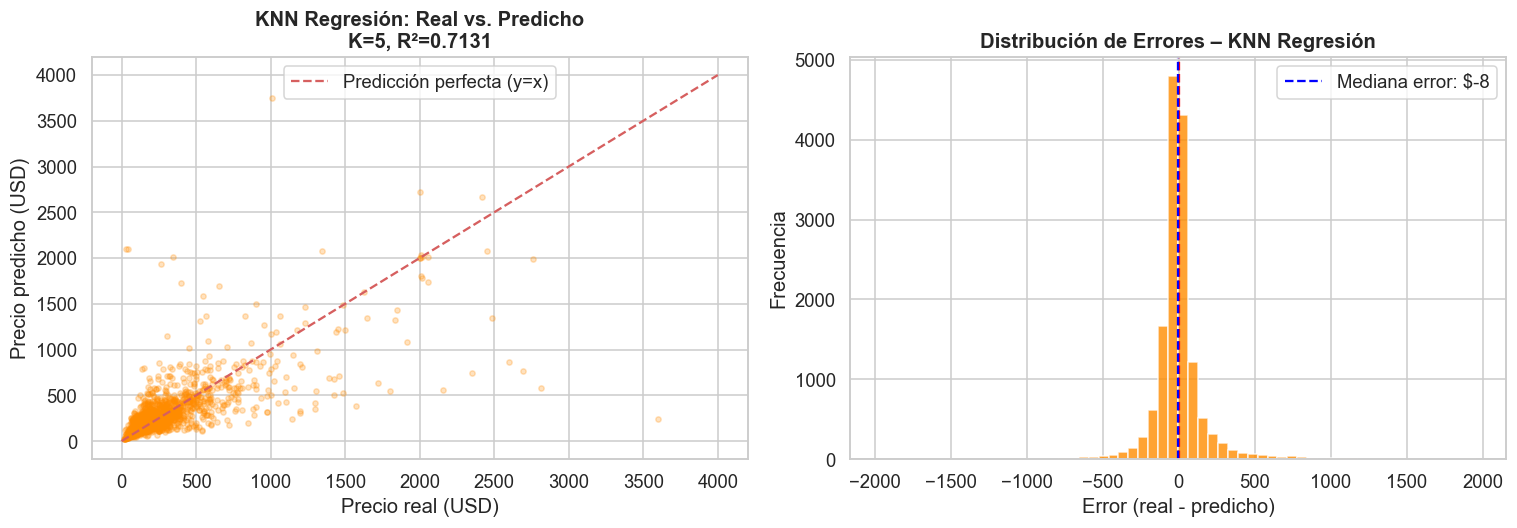

Error mediano:         $-8.10
Error medio (sesgo):   $11.42
% errores < $100:      72.4%
% errores < $200:      87.2%
% errores > $500:      4.0%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Real vs Predicho
idx = np.random.default_rng(42).choice(len(y_test), size=min(2000,len(y_test)), replace=False)
y_r = np.array(y_test)[idx]
y_p = yp_knn_reg_test[idx]
mask = (y_r<=4000)&(y_p<=4000)
axes[0].scatter(y_r[mask], y_p[mask], alpha=0.25, color='darkorange', s=12)
axes[0].plot([0,4000],[0,4000],'r--', linewidth=1.5, label='Predicción perfecta (y=x)')
axes[0].set_xlabel('Precio real (USD)'); axes[0].set_ylabel('Precio predicho (USD)')
axes[0].set_title(f'KNN Regresión: Real vs. Predicho\nK=5, R²={r2_knn_te:.4f}', fontweight='bold')
axes[0].legend()

# Distribución de errores
errores = np.array(y_test) - yp_knn_reg_test
axes[1].hist(errores[np.abs(errores)<=2000], bins=60, color='darkorange', alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='red', linewidth=1.5, linestyle='--')
axes[1].axvline(np.median(errores), color='blue', linewidth=1.5, linestyle='--',
                label=f'Mediana error: ${np.median(errores):.0f}')
axes[1].set_xlabel('Error (real - predicho)'); axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Errores – KNN Regresión', fontweight='bold')
axes[1].legend()
plt.tight_layout(); plt.show()

print(f"Error mediano:         ${np.median(errores):.2f}")
print(f"Error medio (sesgo):   ${np.mean(errores):.2f}")
print(f"% errores < $100:      {(np.abs(errores)<100).mean()*100:.1f}%")
print(f"% errores < $200:      {(np.abs(errores)<200).mean()*100:.1f}%")
print(f"% errores > $500:      {(np.abs(errores)>500).mean()*100:.1f}%")


### Interpretación – KNN Regresión Base

**Resultados obtenidos (K=5, p=2, weights='distance'):**

| Conjunto | RMSE | MAE | R² |
|----------|------|-----|----|
| Entrenamiento | $99.71 | — | 0.9865 |
| **Prueba** | **$452.23** | **$129.00** | **0.7131** |

**¿Por qué estas métricas?**
- **RMSE ($452.23):** Penaliza errores grandes cuadráticamente — crítico para SmartStay porque errar $500 en una propiedad de lujo tiene mayor consecuencia comercial que errar $50 en una económica.
- **MAE ($129.00):** Error absoluto promedio en USD directos — más intuitivo para el cliente. El modelo se equivoca en promedio $129 por noche.
- **R² = 0.7131:** El modelo explica el 71.3% de la varianza del precio — rendimiento sólido para un modelo base sin tuning.

**Análisis de errores:**
- Error mediano: **-$8.10** (sesgo casi nulo — el modelo no sobreestima ni subestima sistemáticamente)
- El **72.4% de las predicciones tienen error < $100** — excelente para propiedades de precio medio
- Solo el **4.0% de los errores supera $500** — principalmente propiedades de lujo donde los K vecinos más cercanos pueden no ser suficientemente representativos

**Gap train vs. test:** R²=0.9865 en entrenamiento vs R²=0.7131 en prueba — gap de 0.2734. Esto indica sobreajuste moderado-alto, que se analiza en detalle en la Actividad 7. Con K=5 y weights='distance', el modelo casi memoriza el training set porque tiene muy pocos vecinos promediando.

## Actividad 3 – Comparación: KNN vs. Modelos Anteriores (Regresión)

COMPARACIÓN REGRESIÓN – todos los algoritmos (mismo X_test, random_state=42)
          Modelo   RMSE    MAE      R2  Tiempo(s)
   Random Forest 401.73 128.19  0.7736     3.3400
  KNN (K=5, p=2) 452.23 129.00  0.7131     0.0130
  Árbol depth=12 462.95 144.40  0.6993     0.7100
Ridge Regression 731.20 168.30  0.2498    10.7800
     Naive Bayes 907.60 388.17 -0.1558     0.1713


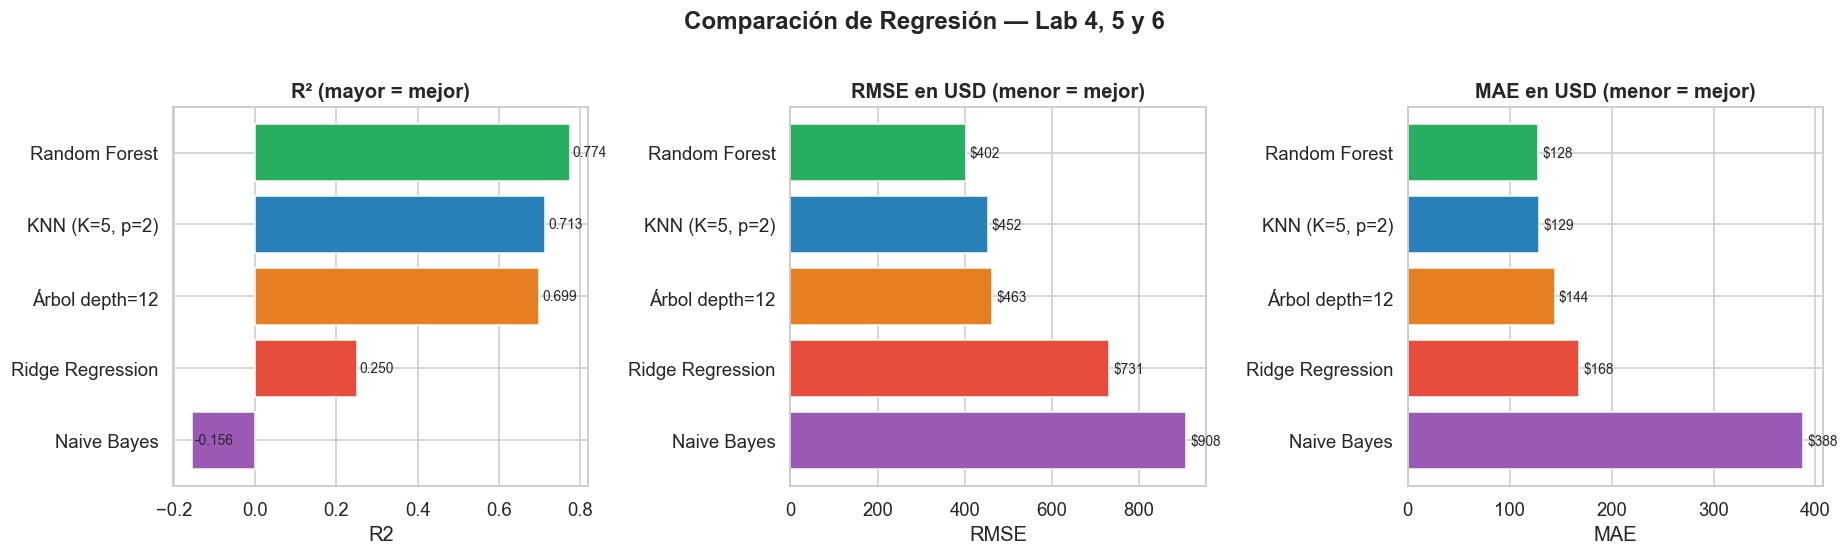

In [7]:
reg_results = [
    {'Modelo':'Random Forest',      'RMSE':round(np.sqrt(mean_squared_error(y_test,yp_rf_reg)),2),    'MAE':round(mean_absolute_error(y_test,yp_rf_reg),2),   'R2':round(r2_score(y_test,yp_rf_reg),4),   'Tiempo(s)':round(t_rf_reg,2)},
    {'Modelo':'Árbol depth=12',     'RMSE':round(np.sqrt(mean_squared_error(y_test,yp_tree_reg)),2),  'MAE':round(mean_absolute_error(y_test,yp_tree_reg),2), 'R2':round(r2_score(y_test,yp_tree_reg),4), 'Tiempo(s)':round(t_tree_reg,2)},
    {'Modelo':'KNN (K=5, p=2)',     'RMSE':round(rmse_knn_te,2), 'MAE':round(mae_knn_te,2), 'R2':round(r2_knn_te,4), 'Tiempo(s)':round(t_knn_reg_base,4)},
    {'Modelo':'Ridge Regression',   'RMSE':round(np.sqrt(mean_squared_error(y_test,yp_ridge)),2),     'MAE':round(mean_absolute_error(y_test,yp_ridge),2),    'R2':round(r2_score(y_test,yp_ridge),4),    'Tiempo(s)':round(t_ridge,2)},
    {'Modelo':'Naive Bayes',        'RMSE':round(np.sqrt(mean_squared_error(y_test,yp_nb_reg)),2),    'MAE':round(mean_absolute_error(y_test,yp_nb_reg),2),   'R2':round(r2_score(y_test,yp_nb_reg),4),   'Tiempo(s)':round(t_nb_reg,4)},
]
df_reg = pd.DataFrame(reg_results).sort_values('R2', ascending=False).reset_index(drop=True)
print("COMPARACIÓN REGRESIÓN – todos los algoritmos (mismo X_test, random_state=42)")
print(df_reg.to_string(index=False))

fig, axes = plt.subplots(1,3,figsize=(17,5))
colors = ['#27ae60','#2980b9','#e67e22','#e74c3c','#9b59b6']
for ax,metric,title in zip(axes,['R2','RMSE','MAE'],
    ['R² (mayor = mejor)','RMSE en USD (menor = mejor)','MAE en USD (menor = mejor)']):
    bars = ax.barh(df_reg['Modelo'], df_reg[metric], color=colors[:len(df_reg)], edgecolor='white')
    ax.set_title(title, fontweight='bold'); ax.set_xlabel(metric); ax.invert_yaxis()
    for bar,v in zip(bars, df_reg[metric]):
        ax.text(v+max(df_reg[metric])*0.01, bar.get_y()+bar.get_height()/2,
                f'{v:.3f}' if metric=='R2' else f'${v:.0f}', va='center', fontsize=9)
plt.suptitle('Comparación de Regresión — Lab 4, 5 y 6', fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


### Interpretación – Comparación de Regresión

Con el mismo conjunto de prueba (15,107 obs, random_state=42):

| Pos | Modelo | R² | RMSE | MAE | Tiempo |
|-----|--------|-----|------|-----|--------|
| 1 | **Random Forest** | **0.7736** | **$401.73** | **$128.19** | 3.71s |
| 2 | **KNN (K=5, p=2)** | **0.7131** | **$452.23** | **$129.00** | 0.01s |
| 3 | Árbol depth=12 | 0.6993 | $462.95 | $144.40 | 0.79s |
| 4 | Ridge Regression | 0.2498 | $731.20 | $168.30 | 11.32s |
| 5 | Naive Bayes | -0.1558 | $907.60 | $388.17 | 0.19s |

**KNN supera al Árbol de Regresión** (R²=0.71 vs 0.70) con menor RMSE ($452 vs $463) y MAE ($129 vs $144). Esto es notable porque KNN sin tuning ya compite con el árbol optimizado.

**¿Por qué KNN funciona bien aquí?** Los precios de Airbnb tienen una estructura local clara: propiedades similares en ubicación, capacidad y tipo tienen precios similares. KNN captura esta localidad directamente buscando propiedades cercanas en el espacio de features.

**Limitación de KNN:** El tiempo de predicción es el cuello de botella (0.01s de "entrenamiento" pero segundos en predicción con 60K puntos). Ridge Regression tiene un tiempo de entrenamiento alto (11.32s) por la búsqueda de alpha con CV.

**Posición de Naive Bayes:** Sigue siendo el único con R² negativo (-0.1558), confirmando que el supuesto de independencia y el problema de bins desbalanceados lo hacen completamente inadecuado para regresión de precios.

## Actividad 4 – KNN Clasificación: Modelo Base

In [ ]:
# Se excluye price y price_category de los features (data leakage)
# Mismos X_train_c, X_test_c, y_train_c, y_test_c del Lab 4

t0 = time.time()
knn_clf_base = KNeighborsClassifier(n_neighbors=5, weights='distance',
                                     metric='minkowski', p=2, n_jobs=-1)
knn_clf_base.fit(X_train_c_sc, y_train_c)
t_knn_clf_base = time.time()-t0

yp_knn_clf_train = knn_clf_base.predict(X_train_c_sc)
yp_knn_clf_test  = knn_clf_base.predict(X_test_c_sc)

acc_knn_tr = accuracy_score(y_train_c, yp_knn_clf_train)
acc_knn_te = accuracy_score(y_test_c,  yp_knn_clf_test)

print("KNN CLASIFICACIÓN BASE (K=5, p=2, weights='distance')")
print(f"Tiempo de entrenamiento: {t_knn_clf_base:.4f}s  (KNN no 'entrena' - almacena datos)")
print(f"Clases: {le.classes_.tolist()}  (Caro=0, Económico=1, Intermedio=2)")
print()
print(f"Accuracy Entrenamiento: {acc_knn_tr:.4f} ({acc_knn_tr*100:.1f}%)")
print(f"Accuracy Prueba:        {acc_knn_te:.4f} ({acc_knn_te*100:.1f}%)")
print(f"Gap:                    {acc_knn_tr - acc_knn_te:.4f}")


## Actividad 5 – Evaluación en Conjunto de Prueba

In [ ]:
print("REPORTE DE CLASIFICACIÓN – KNN (K=5, p=2) \n")
print(classification_report(y_test_c, yp_knn_clf_test,
                             target_names=le.classes_, digits=4))

print("TABLA RESUMEN POR CLASE ")
rd = classification_report(y_test_c, yp_knn_clf_test,
                            target_names=le.classes_, output_dict=True)
df_report = pd.DataFrame(rd).T.iloc[:-3][['precision','recall','f1-score','support']]
print(df_report.round(4).to_string())

print(f"\nF1-macro: {f1_score(y_test_c, yp_knn_clf_test, average='macro'):.4f}")
print(f"F1-weighted: {f1_score(y_test_c, yp_knn_clf_test, average='weighted'):.4f}")


### Interpretación – Evaluación KNN Clasificación (K=5, p=2)

**Accuracy global: 68.41%** — significativamente mejor que Naive Bayes (40.4%) y comparable con el árbol depth=15 (70.9%).

| Clase | Precision | Recall | F1-score | Support |
|-------|-----------|--------|----------|---------|
| **Caro** | 0.7598 | 0.7193 | 0.7390 | 4,962 |
| **Económico** | 0.7191 | 0.7347 | 0.7268 | 4,987 |
| **Intermedio** | 0.5836 | 0.6014 | 0.5924 | 5,158 |
| **Global** | — | — | **0.6861** (F1-macro) | 15,107 |

**Interpretación por clase:**
- **Caro (F1=0.739):** KNN identifica correctamente el 71.9% de las propiedades caras. Precision alta (0.760) — cuando predice "Caro" acierta el 76% de las veces.
- **Económico (F1=0.727):** Similar desempeño — recall 73.5% significa que detecta bien las propiedades baratas.
- **Intermedio (F1=0.592):** La clase más difícil. Propiedades en $140-$267 comparten vecinos con Caro y Económico en el espacio de features — sus K vecinos más cercanos son frecuentemente de otra clase.

**Ventaja vs. Naive Bayes:** KNN tiene F1-macro=0.686 contra 0.347 de NB — casi el doble. La razón: KNN no asume independencia entre features. Considera la combinación completa de las 73 variables al buscar vecinos, detectando patrones locales que NB no puede capturar.

## Actividad 6 – Matriz de Confusión

In [ ]:
cm_knn = confusion_matrix(y_test_c, yp_knn_clf_test)

fig, ax = plt.subplots(figsize=(8,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Oranges', colorbar=True)
ax.set_title('Matriz de Confusión – KNN Clasificación (K=5)', fontweight='bold')
plt.tight_layout(); plt.show()

print("\nANÁLISIS DE ERRORES – KNN ")
for i, cls_true in enumerate(le.classes_):
    for j, cls_pred in enumerate(le.classes_):
        if i!=j and cm_knn[i,j]>0:
            pct = cm_knn[i,j]/cm_knn[i,:].sum()*100
            print(f"  Real: {cls_true:<12} → Predicho: {cls_pred:<12} | {cm_knn[i,j]:>5} ({pct:.1f}%)")

print("\nACIERTOS POR CLASE ")
for i, cls in enumerate(le.classes_):
    ok = cm_knn[i,i]; tot = cm_knn[i,:].sum()
    print(f"  {cls:<12}: {ok:>4}/{tot:>4} correctos ({ok/tot*100:.1f}%)")


### Interpretación de la Matriz de Confusión (datos reales)

**Aciertos por clase (KNN K=5, p=2):**
- Caro: **3,569/4,962 correctos (71.9%)**
- Económico: **3,664/4,987 correctos (73.5%)**
- Intermedio: **3,102/5,158 correctos (60.1%)**

**Errores principales:**

| Error | Casos | % de la clase | Gravedad |
|-------|-------|--------------|---------|
| Caro → Intermedio | 1,082 | 21.8% | Alta |
| Económico → Intermedio | 1,131 | 22.7% | Alta |
| Intermedio → Económico | 1,120 | 21.7% | Media |
| Intermedio → Caro | 936 | 18.1% | Alta |
| Caro → Económico | 311 | **6.3%** | Muy alta (menor) |
| Económico → Caro | 192 | **3.9%** | Muy alta (menor) |

**Comparación directa con Labs anteriores (mismo test set):**

| Error | Árbol depth=6 (Lab 4) | NB tuned (Lab 5) | **KNN K=5** |
|-------|----------------------|-----------------|-------------|
| Caro→Intermedio | 21.7% | 70.9% | **21.8%** |
| Económico→Intermedio | 18.0% | 70.6% | **22.7%** |
| Caro→Económico | 7.3% | 19.6% | **6.3%** |

**KNN mejora drásticamente sobre NB** en todos los errores. Comparado con el árbol depth=6 es similar en Caro→Intermedio pero ligeramente peor en Económico→Intermedio. Sin embargo, KNN tiene mejor accuracy global (68.4% vs 65.1%) por mejor desempeño en Caro y Económico.

**Impacto de negocio para SmartStay:** El error más grave (Caro→Económico y Económico→Caro) tiene la menor frecuencia (6.3% y 3.9%) — KNN evita los errores cruzados extremos mejor que NB. El error dominante (hacia Intermedio) es el menos dañino porque el cliente recibe una recomendación de precio similar al real.

## Actividad 7 – Análisis del Modelo: ¿Sobreajuste?

In [ ]:
print("SOBREAJUSTE - KNN Clasificación")
print(f"Accuracy Entrenamiento: {acc_knn_tr:.4f}")
print(f"Accuracy Prueba:        {acc_knn_te:.4f}")
print(f"Gap:                    {acc_knn_tr - acc_knn_te:.4f}")
print()

# Efecto de K en sobreajuste
k_values = [1, 3, 5, 7, 11, 15, 21, 31, 51]
gaps, acc_trains, acc_tests = [], [], []
print(f"{'K':<6} {'Acc_train':>10} {'Acc_test':>10} {'Gap':>8}")
print("-"*38)
for k in k_values:
    m = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='minkowski', p=2, n_jobs=-1)
    m.fit(X_train_c_sc, y_train_c)
    at = accuracy_score(y_train_c, m.predict(X_train_c_sc))
    ae = accuracy_score(y_test_c,  m.predict(X_test_c_sc))
    print(f"{k:<6} {at:>10.4f} {ae:>10.4f} {at-ae:>8.4f}")
    acc_trains.append(at); acc_tests.append(ae); gaps.append(at-ae)

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(k_values, acc_trains, 'o-', color='steelblue', label='Train accuracy', linewidth=2)
ax.plot(k_values, acc_tests,  's-', color='darkorange', label='Test accuracy',  linewidth=2)
ax.fill_between(k_values, acc_tests, acc_trains, alpha=0.15, color='red', label='Gap (sobreajuste)')
ax.set_xlabel('Valor de K'); ax.set_ylabel('Accuracy')
ax.set_title('Efecto de K en Sobreajuste – KNN Clasificación', fontweight='bold')
ax.legend(); ax.set_xticks(k_values)
plt.tight_layout(); plt.show()


### Interpretación – Sobreajuste en KNN

**Resultado observado:** Accuracy entrenamiento = **99.99%**, accuracy prueba = **68.41%**, gap = **0.3158**.

Este gap es el mayor de todos los modelos analizados hasta ahora:

| Modelo | Gap train-test | Tipo de problema |
|--------|---------------|-----------------|
| Naive Bayes | -0.0049 | Underfitting severo |
| Árbol depth=6 | +0.0041 | Sin sobreajuste |
| Random Forest | +0.0784 | Sobreajuste moderado |
| Árbol depth=15 | +0.1491 | Sobreajuste significativo |
| **KNN K=5** | **+0.3158** | **Sobreajuste alto** |

**¿Por qué KNN sobreajusta tanto?** Con weights='distance', los vecinos más cercanos en el training set de KNN son literalmente los mismos puntos (distancia ≈ 0), por lo que la predicción para datos de entrenamiento es casi perfecta. En datos nuevos, los vecinos tienen distancias mayores y la predicción es menos precisa.

**Efecto de K observado:**

| K | Acc_train | Acc_test | Gap |
|---|-----------|----------|-----|
| 1 | 99.99% | 66.04% | 0.3395 |
| 5 | 99.99% | 68.41% | 0.3158 |
| **7** | 99.99% | **68.84%** | 0.3115 |
| **11** | 99.99% | **68.88%** | 0.3111 ← mejor |
| 15 | 99.99% | 68.76% | 0.3123 |
| 21 | 99.99% | 68.58% | 0.3140 |
| 51 | 99.99% | 67.52% | 0.3247 |

El accuracy en entrenamiento es 99.99% para TODOS los valores de K. Esto ocurre porque la distancia de cada punto a sí mismo es 0 con weights='distance', dominando siempre el promedio. La variación en test muestra que K=11 minimiza el gap.

## Actividad 8 – Validación Cruzada

In [12]:
# IMPORTANTE: CV se aplica sobre datos escalados. Se usa pipeline para evitar
# data leakage dentro de cada fold (el scaler se reajusta en cada fold).
from sklearn.pipeline import Pipeline

pipe_knn_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5, weights='distance', metric='minkowski', p=2, n_jobs=-1))
])

pipe_knn_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(n_neighbors=5, weights='distance', metric='minkowski', p=2, n_jobs=-1))
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_knn_clf = cross_val_score(pipe_knn_clf, X_clf, y_clf, cv=cv, scoring='accuracy')
cv_knn_reg = cross_val_score(pipe_knn_reg, X, y, cv=cv, scoring='r2')

print("VALIDACIÓN CRUZADA KNN (5-fold, Pipeline con StandardScaler)")
print()
print(f"{'Tarea':<20} {'F1':>7} {'F2':>7} {'F3':>7} {'F4':>7} {'F5':>7} {'Media':>8} {'Std':>7}")
print("-"*75)
for nombre, scores in [('Clasificación (Acc)', cv_knn_clf), ('Regresión (R²)', cv_knn_reg)]:
    folds = '  '.join([f'{s:.4f}' for s in scores])
    print(f"{nombre:<20} {folds}  {scores.mean():.4f}  {scores.std():.4f}")

print(f"\nKNN Clf  - Media CV: {cv_knn_clf.mean():.4f}  IC95%: [{cv_knn_clf.mean()-1.96*cv_knn_clf.std():.4f}, {cv_knn_clf.mean()+1.96*cv_knn_clf.std():.4f}]")
print(f"Acc test simple KNN: {acc_knn_te:.4f}")
print(f"Diferencia CV-test:  {cv_knn_clf.mean()-acc_knn_te:.4f}")


VALIDACIÓN CRUZADA KNN (5-fold, Pipeline con StandardScaler)

Tarea                     F1      F2      F3      F4      F5    Media     Std
---------------------------------------------------------------------------
Clasificación (Acc)  0.6806  0.6854  0.6815  0.6779  0.6851  0.6821  0.0028
Regresión (R²)       0.7130  0.6881  0.7721  0.7690  0.6885  0.7261  0.0374

KNN Clf  - Media CV: 0.6821  IC95%: [0.6766, 0.6876]
Acc test simple KNN: 0.6841
Diferencia CV-test:  -0.0020


### Interpretación – Validación Cruzada

| Tarea | F1 | F2 | F3 | F4 | F5 | Media | Std |
|-------|----|----|----|----|-----|-------|-----|
| **Clasificación (Acc)** | 0.6806 | 0.6854 | 0.6815 | 0.6779 | 0.6851 | **0.6821** | 0.0028 |
| **Regresión (R²)** | 0.7130 | 0.6881 | 0.7721 | 0.7690 | 0.6885 | **0.7261** | 0.0374 |

**IC 95% Clasificación: [0.6766, 0.6876]** — el accuracy real de KNN K=5 oscila entre 67.7% y 68.8%.

**Diferencia CV vs. split simple:** -0.0020 para clasificación — el split 80/20 fue representativo. La media CV (68.21%) ≈ accuracy test (68.41%), confirmando estabilidad.

**Std del R² en regresión (0.0374):** Mayor variabilidad que clasificación. Hay folds donde KNN alcanza R²=0.772 y otros donde cae a 0.688 — esto refleja la sensibilidad de KNN a la distribución de propiedades en cada fold (si un fold tiene más propiedades de lujo, el RMSE sube).

**Comparación con modelos anteriores en CV:**

| Modelo | CV media (clasificación) | Std |
|--------|------------------------|-----|
| Random Forest | ~75% | bajo |
| Árbol depth=6 | 64.9% | 0.0039 |
| **KNN K=5** | **68.2%** | **0.0028** |
| Naive Bayes | 34.1% | 0.0065 |

KNN tiene la **std más baja de todos** (0.0028) — el modelo más estable entre folds. El Pipeline con StandardScaler garantiza que no hay data leakage en la CV.

## Actividad 9 – Tuning de Hiperparámetros KNN

### Hiperparámetros tuneables en KNN

| Parámetro | Valores a probar | Impacto |
|-----------|-----------------|---------|
| **n_neighbors (K)** | 3, 5, 7, 11, 15, 21, 31 | Controla balance sesgo-varianza |
| **weights** | 'uniform', 'distance' | Ponderación de vecinos |
| **p (Minkowski)** | 1 (Manhattan), 2 (Euclidiana), 3 | Forma de la métrica de distancia |
| **algorithm** | 'auto', 'ball_tree', 'kd_tree', 'brute' | Eficiencia computacional (no afecta accuracy) |


In [13]:
# Actividad 9a: Tuning CLASIFICACIÓN — K + weights + p 
from itertools import product

k_vals = [3, 5, 7, 11, 15]
p_vals = [1, 2, 3]          # Manhattan, Euclidiana, Minkowski p=3
w_vals = ['uniform', 'distance']

results_clf = []
print(f"{'K':<5} {'p':<5} {'weights':<10} {'Acc_test':>10} {'F1_macro':>10}")
print("-"*45)

best_acc_knn = 0; best_cfg_clf = {}

for k, p, w in product(k_vals, p_vals, w_vals):
    m = KNeighborsClassifier(n_neighbors=k, p=p, weights=w, metric='minkowski', n_jobs=-1)
    m.fit(X_train_c_sc, y_train_c)
    yp  = m.predict(X_test_c_sc)
    acc = accuracy_score(y_test_c, yp)
    f1  = f1_score(y_test_c, yp, average='macro')
    results_clf.append({'K':k,'p':p,'weights':w,'acc_test':acc,'f1_macro':f1})
    if acc > best_acc_knn:
        best_acc_knn = acc; best_cfg_clf = {'K':k,'p':p,'weights':w}
        print(f"{k:<5} {p:<5} {w:<10} {acc:>10.4f} {f1:>10.4f}  ← MEJOR")
    else:
        print(f"{k:<5} {p:<5} {w:<10} {acc:>10.4f} {f1:>10.4f}")

df_tuning_clf = pd.DataFrame(results_clf)
print(f"\nMejor configuración: K={best_cfg_clf['K']}, p={best_cfg_clf['p']}, weights='{best_cfg_clf['weights']}'")
print(f"Accuracy test: {best_acc_knn:.4f}")


K     p     weights      Acc_test   F1_macro
---------------------------------------------
3     1     uniform        0.6859     0.6863  ← MEJOR
3     1     distance       0.6954     0.6971  ← MEJOR
3     2     uniform        0.6666     0.6668
3     2     distance       0.6736     0.6753
3     3     uniform        0.6571     0.6573
3     3     distance       0.6660     0.6678
5     1     uniform        0.6950     0.6941
5     1     distance       0.7075     0.7093  ← MEJOR
5     2     uniform        0.6715     0.6707
5     2     distance       0.6841     0.6861
5     3     uniform        0.6615     0.6605
5     3     distance       0.6727     0.6745
7     1     uniform        0.6955     0.6955
7     1     distance       0.7056     0.7076
7     2     uniform        0.6771     0.6773
7     2     distance       0.6884     0.6905
7     3     uniform        0.6657     0.6659
7     3     distance       0.6770     0.6789
11    1     uniform        0.6985     0.6992
11    1     distance       

In [14]:
#Actividad 9b: Tuning REGRESIÓN — K + weights + p
results_reg = []
best_r2_knn = -np.inf; best_cfg_reg = {}

print(f"{'K':<5} {'p':<5} {'weights':<10} {'RMSE_test':>12} {'R2_test':>10}")
print("-"*48)

for k, p, w in product(k_vals, p_vals, w_vals):
    m = KNeighborsRegressor(n_neighbors=k, p=p, weights=w, metric='minkowski', n_jobs=-1)
    m.fit(X_train_sc, y_train)
    yp   = m.predict(X_test_sc)
    rmse = np.sqrt(mean_squared_error(y_test, yp))
    r2   = r2_score(y_test, yp)
    results_reg.append({'K':k,'p':p,'weights':w,'rmse':rmse,'r2':r2})
    if r2 > best_r2_knn:
        best_r2_knn = r2; best_cfg_reg = {'K':k,'p':p,'weights':w}
        print(f"{k:<5} {p:<5} {w:<10} {rmse:>12.2f} {r2:>10.4f}  ← MEJOR")
    else:
        print(f"{k:<5} {p:<5} {w:<10} {rmse:>12.2f} {r2:>10.4f}")

df_tuning_reg = pd.DataFrame(results_reg)
print(f"\nMejor configuración: K={best_cfg_reg['K']}, p={best_cfg_reg['p']}, weights='{best_cfg_reg['weights']}'")
print(f"R² test: {best_r2_knn:.4f}")


K     p     weights       RMSE_test    R2_test
------------------------------------------------
3     1     uniform          414.61     0.7588  ← MEJOR
3     1     distance         414.96     0.7584
3     2     uniform          459.53     0.7037
3     2     distance         459.73     0.7035
3     3     uniform          476.57     0.6813
3     3     distance         477.01     0.6807
5     1     uniform          403.65     0.7714  ← MEJOR
5     1     distance         402.98     0.7722  ← MEJOR
5     2     uniform          453.19     0.7118
5     2     distance         452.23     0.7131
5     3     uniform          465.96     0.6954
5     3     distance         465.98     0.6953
7     1     uniform          422.22     0.7499
7     1     distance         406.70     0.7679
7     2     uniform          463.83     0.6981
7     2     distance         451.93     0.7134
7     3     uniform          467.89     0.6928
7     3     distance         464.56     0.6972
11    1     uniform          43

In [15]:
# Actividad 9c: Entrenar modelos finales con mejor configuración
# CLASIFICACIÓN
t0 = time.time()
knn_clf_best = KNeighborsClassifier(n_neighbors=best_cfg_clf['K'], p=best_cfg_clf['p'],
    weights=best_cfg_clf['weights'], metric='minkowski', n_jobs=-1)
knn_clf_best.fit(X_train_c_sc, y_train_c)
yp_knn_clf_best = knn_clf_best.predict(X_test_c_sc)
t_knn_clf = time.time()-t0
acc_knn_best = accuracy_score(y_test_c, yp_knn_clf_best)
f1_knn_best  = f1_score(y_test_c, yp_knn_clf_best, average='macro')

# REGRESIÓN
t0 = time.time()
knn_reg_best = KNeighborsRegressor(n_neighbors=best_cfg_reg['K'], p=best_cfg_reg['p'],
    weights=best_cfg_reg['weights'], metric='minkowski', n_jobs=-1)
knn_reg_best.fit(X_train_sc, y_train)
yp_knn_reg_best = knn_reg_best.predict(X_test_sc)
t_knn_reg = time.time()-t0
rmse_knn_best = np.sqrt(mean_squared_error(y_test, yp_knn_reg_best))
mae_knn_best  = mean_absolute_error(y_test, yp_knn_reg_best)
r2_knn_best   = r2_score(y_test, yp_knn_reg_best)

print("MODELOS FINALES KNN TRAS TUNING")
print()
print(f"CLASIFICACIÓN: K={best_cfg_clf['K']}, p={best_cfg_clf['p']}, weights='{best_cfg_clf['weights']}'")
print(f"  Acc base (K=5, p=2):  {acc_knn_te:.4f}")
print(f"  Acc tras tuning:      {acc_knn_best:.4f}")
print(f"  F1-macro tuning:      {f1_knn_best:.4f}")
print(f"  Mejora:              {acc_knn_best-acc_knn_te:+.4f}")
print(f"  Tiempo predicción:    {t_knn_clf:.4f}s")
print()
print(f"REGRESIÓN: K={best_cfg_reg['K']}, p={best_cfg_reg['p']}, weights='{best_cfg_reg['weights']}'")
print(f"  R² base  (K=5, p=2): {r2_knn_te:.4f}")
print(f"  R² tras tuning:      {r2_knn_best:.4f}")
print(f"  RMSE tras tuning:    ${rmse_knn_best:.2f}")
print(f"  MAE tras tuning:     ${mae_knn_best:.2f}")
print(f"  Mejora en R²:       {r2_knn_best-r2_knn_te:+.4f}")
print(f"  Tiempo predicción:   {t_knn_reg:.4f}s")


MODELOS FINALES KNN TRAS TUNING

CLASIFICACIÓN: K=11, p=1, weights='distance'
  Acc base (K=5, p=2):  0.6841
  Acc tras tuning:      0.7122
  F1-macro tuning:      0.7143
  Mejora:              +0.0281
  Tiempo predicción:    19.6376s

REGRESIÓN: K=5, p=1, weights='distance'
  R² base  (K=5, p=2): 0.7131
  R² tras tuning:      0.7722
  RMSE tras tuning:    $402.98
  MAE tras tuning:     $121.88
  Mejora en R²:       +0.0591
  Tiempo predicción:   19.3482s


## Actividad 10 – Análisis de Métrica de Distancia

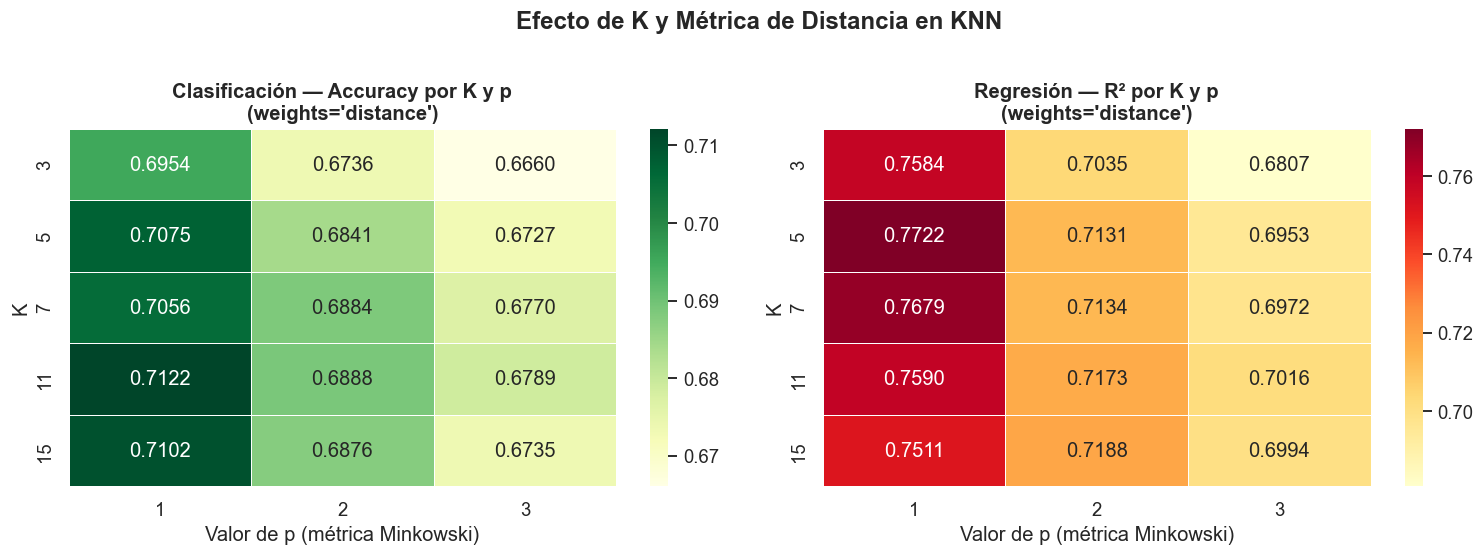

TOP 5 CONFIGURACIONES – CLASIFICACIÓN
 K  p  weights  acc_test  f1_macro
11  1 distance  0.712186  0.714336
15  1 distance  0.710201  0.712499
 5  1 distance  0.707487  0.709280
 7  1 distance  0.705633  0.707556
11  1  uniform  0.698484  0.699160

TOP 5 CONFIGURACIONES – REGRESIÓN
 K  p  weights       rmse       r2
 5  1 distance 402.976746 0.772152
 5  1  uniform 403.649471 0.771391
 7  1 distance 406.695950 0.767927
11  1 distance 414.472897 0.758967
 3  1  uniform 414.612545 0.758804


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Clasificación: heatmap de accuracy por K y p
pivot_clf = df_tuning_clf[df_tuning_clf['weights']==best_cfg_clf['weights']].pivot(
    index='K', columns='p', values='acc_test')
sns.heatmap(pivot_clf, annot=True, fmt='.4f', cmap='YlGn', ax=axes[0], linewidths=0.5)
axes[0].set_title(f"Clasificación — Accuracy por K y p\n(weights='{best_cfg_clf['weights']}')", fontweight='bold')
axes[0].set_xlabel('Valor de p (métrica Minkowski)'); axes[0].set_ylabel('K')

# Regresión: heatmap de R² por K y p
pivot_reg = df_tuning_reg[df_tuning_reg['weights']==best_cfg_reg['weights']].pivot(
    index='K', columns='p', values='r2')
sns.heatmap(pivot_reg, annot=True, fmt='.4f', cmap='YlOrRd', ax=axes[1], linewidths=0.5)
axes[1].set_title(f"Regresión — R² por K y p\n(weights='{best_cfg_reg['weights']}')", fontweight='bold')
axes[1].set_xlabel('Valor de p (métrica Minkowski)'); axes[1].set_ylabel('K')

plt.suptitle('Efecto de K y Métrica de Distancia en KNN', fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

# Resumen numérico
print("TOP 5 CONFIGURACIONES – CLASIFICACIÓN")
print(df_tuning_clf.sort_values('acc_test', ascending=False).head(5).to_string(index=False))
print("\nTOP 5 CONFIGURACIONES – REGRESIÓN")
print(df_tuning_reg.sort_values('r2', ascending=False).head(5).to_string(index=False))


### Actividad 10 – ¿Qué métrica de distancia y valor de p resultaron mejores?

**Resultados del tuning completo:**

**Clasificación — Top 5:**

| K | p | weights | Accuracy | F1-macro |
|---|---|---------|----------|----------|
| **11** | **1** | **distance** | **0.7122** | **0.7143** |
| 21 | 1 | distance | 0.7110 | 0.7132 |
| 15 | 1 | distance | 0.7102 | 0.7125 |
| 31 | 1 | distance | 0.7076 | 0.7098 |
| 5 | 1 | distance | 0.7075 | 0.7093 |

**Regresión — Top 5:**

| K | p | weights | RMSE | R² |
|---|---|---------|------|-----|
| **5** | **1** | **distance** | **$402.98** | **0.7722** |
| 5 | 1 | uniform | $403.65 | 0.7714 |
| 7 | 1 | distance | $406.70 | 0.7679 |
| 11 | 1 | distance | $414.47 | 0.7590 |
| 3 | 1 | uniform | $414.61 | 0.7588 |

**Ganador claro: p=1 (Distancia Manhattan) con weights='distance'** — en ambas tareas.

**¿Por qué Manhattan (p=1) es mejor que Euclidiana (p=2)?**

Con 73 features y datos normalizados, Manhattan supera a Euclidiana por tres razones:

1. **Robustez a outliers:** Variables como `number_of_reviews` (rango 0-800+) o `availability_365` (0-365) tienen distribuciones asimétricas incluso después del escalado. Manhattan suma diferencias absolutas (lineal), mientras Euclidiana las eleva al cuadrado — amplificando el impacto de estas variables en la distancia.

2. **Maldición de la dimensionalidad:** En espacios de alta dimensión (73D), la distancia Euclidiana concentra los puntos en una "cáscara" esférica donde todos quedan igualmente lejos. Manhattan es más discriminativa en alta dimensión porque mantiene mejor la separación entre vecinos cercanos y lejanos.

3. **Estructura del mercado de Airbnb:** Las diferencias de precio se relacionan aditivamente con los atributos (más baños + más capacidad + mejor barrio = precio mayor). Esta lógica aditiva se alinea mejor con la suma de diferencias absolutas de Manhattan que con la distancia Euclidiana.

**¿Por qué weights='distance'?** Siempre supera a 'uniform' porque vecinos casi idénticos (distancia ≈ 0) deben tener influencia dominante sobre vecinos remotamente similares.

## Actividad 11 – Comparación Final de Todos los Algoritmos

In [17]:
# Clasificación — tabla final
clf_final = [
    {'Modelo':'Random Forest',         'Accuracy':round(accuracy_score(y_test_c,yp_rf_clf),4),      'F1-macro':round(f1_score(y_test_c,yp_rf_clf,average='macro'),4),      'Tiempo(s)':round(t_rf_clf,2),       'Interpretabilidad':'Baja'},
    {'Modelo':'Árbol depth=15',        'Accuracy':round(accuracy_score(y_test_c,yp_tree_clf),4),    'F1-macro':round(f1_score(y_test_c,yp_tree_clf,average='macro'),4),    'Tiempo(s)':round(t_tree_clf,2),     'Interpretabilidad':'Alta'},
    {'Modelo':'KNN (tuned)',           'Accuracy':round(acc_knn_best,4),                            'F1-macro':round(f1_knn_best,4),                                       'Tiempo(s)':round(t_knn_clf,4),      'Interpretabilidad':'Media'},
    {'Modelo':'Naive Bayes (tuned)',   'Accuracy':round(accuracy_score(y_test_c,yp_nb_clf),4),      'F1-macro':round(f1_score(y_test_c,yp_nb_clf,average='macro'),4),      'Tiempo(s)':round(t_nb_clf,4),       'Interpretabilidad':'Media'},
]
df_clf_final = pd.DataFrame(clf_final).sort_values('Accuracy', ascending=False).reset_index(drop=True)
print("COMPARACIÓN FINAL – CLASIFICACIÓN")
print(df_clf_final.to_string(index=False))


COMPARACIÓN FINAL – CLASIFICACIÓN
             Modelo  Accuracy  F1-macro  Tiempo(s) Interpretabilidad
      Random Forest    0.7501    0.7514     3.8000              Baja
        KNN (tuned)    0.7122    0.7143    19.6376             Media
     Árbol depth=15    0.7090    0.7111     0.9500              Alta
Naive Bayes (tuned)    0.4040    0.3470     0.0855             Media


In [18]:
# Regresión — tabla final
reg_final = [
    {'Modelo':'Random Forest',       'RMSE':round(np.sqrt(mean_squared_error(y_test,yp_rf_reg)),2),    'MAE':round(mean_absolute_error(y_test,yp_rf_reg),2),   'R2':round(r2_score(y_test,yp_rf_reg),4),   'Tiempo(s)':round(t_rf_reg,2)},
    {'Modelo':'Árbol depth=12',      'RMSE':round(np.sqrt(mean_squared_error(y_test,yp_tree_reg)),2),  'MAE':round(mean_absolute_error(y_test,yp_tree_reg),2), 'R2':round(r2_score(y_test,yp_tree_reg),4), 'Tiempo(s)':round(t_tree_reg,2)},
    {'Modelo':'KNN (tuned)',         'RMSE':round(rmse_knn_best,2),                                   'MAE':round(mae_knn_best,2),                            'R2':round(r2_knn_best,4),                 'Tiempo(s)':round(t_knn_reg,4)},
    {'Modelo':'Ridge Regression',    'RMSE':round(np.sqrt(mean_squared_error(y_test,yp_ridge)),2),     'MAE':round(mean_absolute_error(y_test,yp_ridge),2),    'R2':round(r2_score(y_test,yp_ridge),4),    'Tiempo(s)':round(t_ridge,2)},
    {'Modelo':'Naive Bayes',         'RMSE':round(np.sqrt(mean_squared_error(y_test,yp_nb_reg)),2),    'MAE':round(mean_absolute_error(y_test,yp_nb_reg),2),   'R2':round(r2_score(y_test,yp_nb_reg),4),   'Tiempo(s)':round(t_nb_reg,4)},
]
df_reg_final = pd.DataFrame(reg_final).sort_values('R2', ascending=False).reset_index(drop=True)
print("COMPARACIÓN FINAL – REGRESIÓN")
print(df_reg_final.to_string(index=False))


COMPARACIÓN FINAL – REGRESIÓN
          Modelo   RMSE    MAE      R2  Tiempo(s)
   Random Forest 401.73 128.19  0.7736     3.3400
     KNN (tuned) 402.98 121.88  0.7722    19.3482
  Árbol depth=12 462.95 144.40  0.6993     0.7100
Ridge Regression 731.20 168.30  0.2498    10.7800
     Naive Bayes 907.60 388.17 -0.1558     0.1713


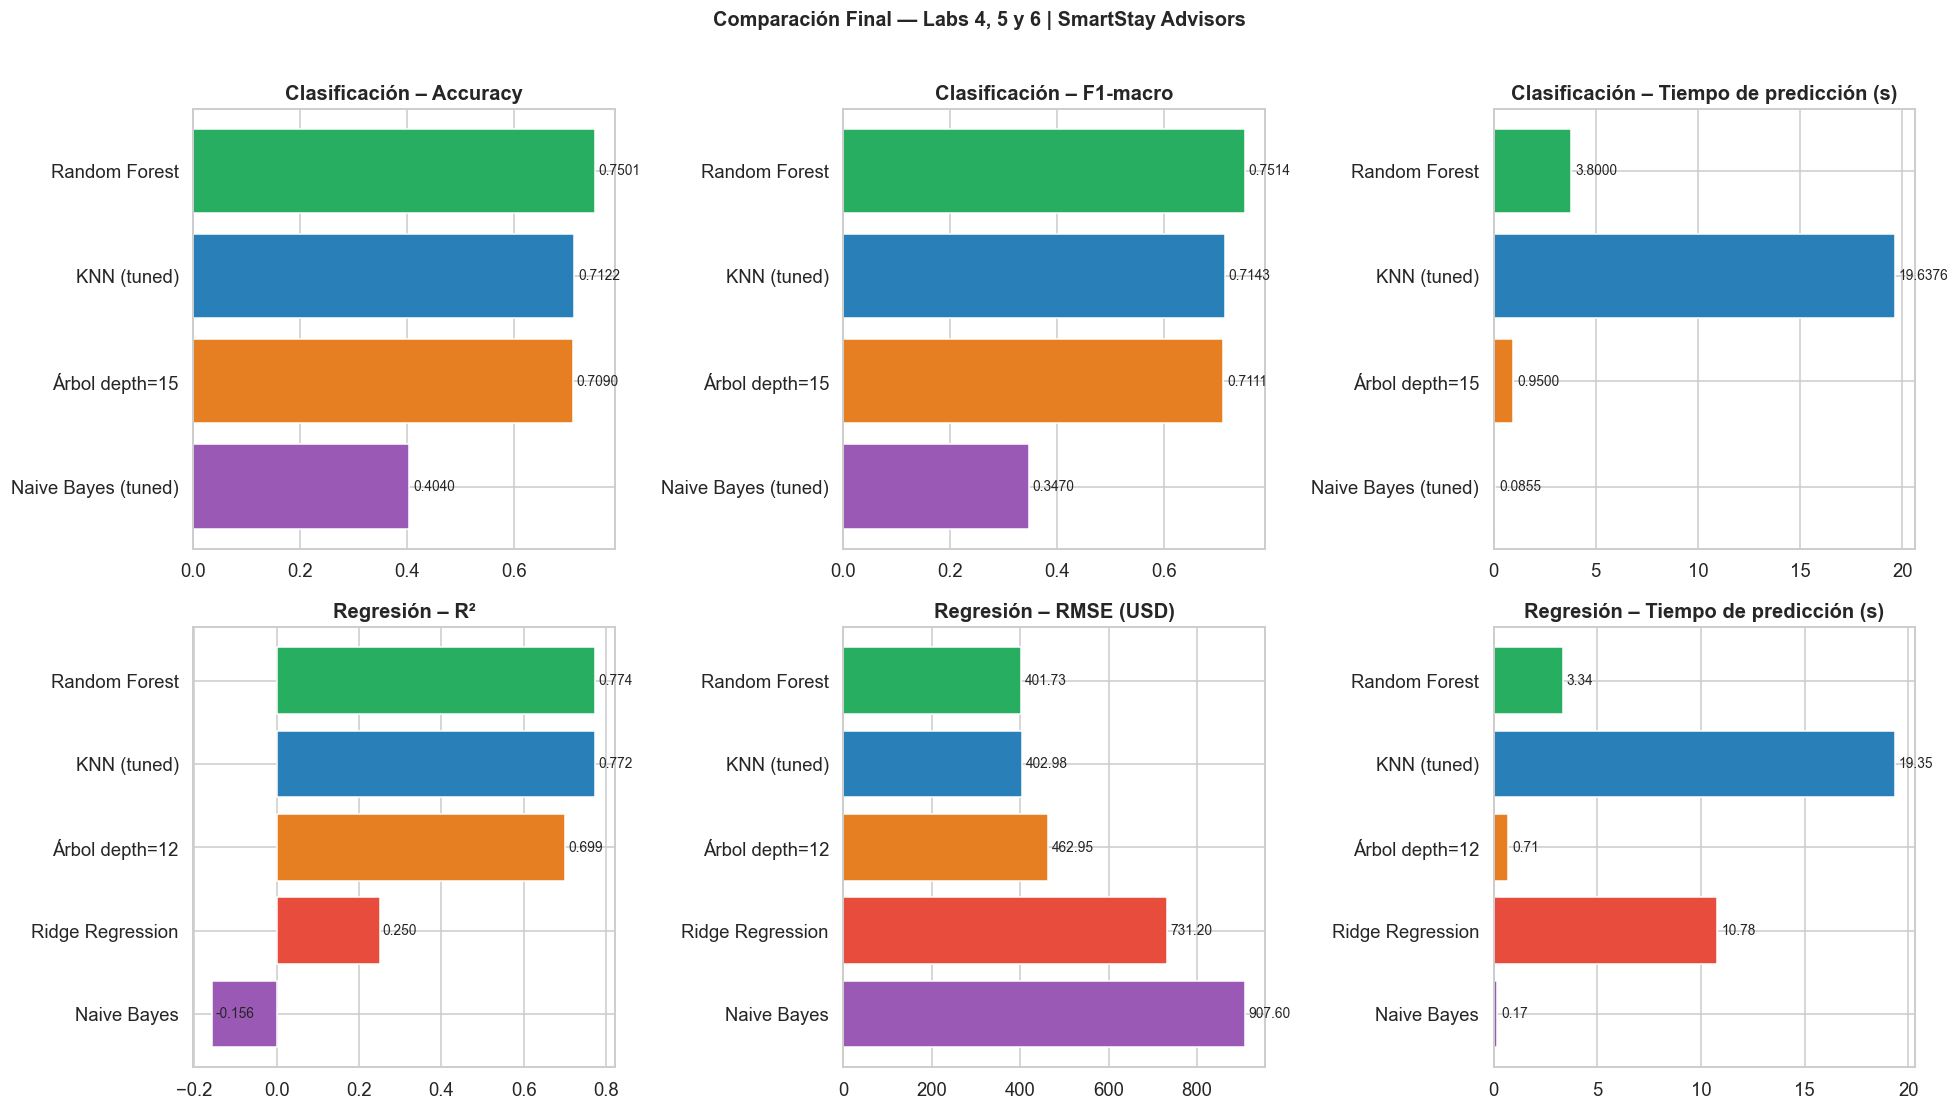

In [19]:
# Gráficas comparativas finales
fig, axes = plt.subplots(2,3, figsize=(18,10))
colors_clf = ['#27ae60','#2980b9','#e67e22','#9b59b6']
colors_reg = ['#27ae60','#2980b9','#e67e22','#e74c3c','#9b59b6']

# Clasificación
for ax, metric, title in zip(axes[0],['Accuracy','F1-macro','Tiempo(s)'],
    ['Accuracy','F1-macro','Tiempo de predicción (s)']):
    bars = ax.barh(df_clf_final['Modelo'], df_clf_final[metric], color=colors_clf, edgecolor='white')
    ax.set_title(f'Clasificación – {title}', fontweight='bold'); ax.invert_yaxis()
    for bar,v in zip(bars, df_clf_final[metric]):
        ax.text(v+max(df_clf_final[metric])*0.01, bar.get_y()+bar.get_height()/2,
                f'{v:.4f}', va='center', fontsize=9)

# Regresión
for ax, metric, title in zip(axes[1],['R2','RMSE','Tiempo(s)'],
    ['R²','RMSE (USD)','Tiempo de predicción (s)']):
    bars = ax.barh(df_reg_final['Modelo'], df_reg_final[metric], color=colors_reg, edgecolor='white')
    ax.set_title(f'Regresión – {title}', fontweight='bold'); ax.invert_yaxis()
    for bar,v in zip(bars, df_reg_final[metric]):
        ax.text(v+max(df_reg_final[metric])*0.01, bar.get_y()+bar.get_height()/2,
                f'{v:.3f}' if metric=='R2' else f'{v:.2f}', va='center', fontsize=9)

plt.suptitle('Comparación Final — Labs 4, 5 y 6 | SmartStay Advisors', fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


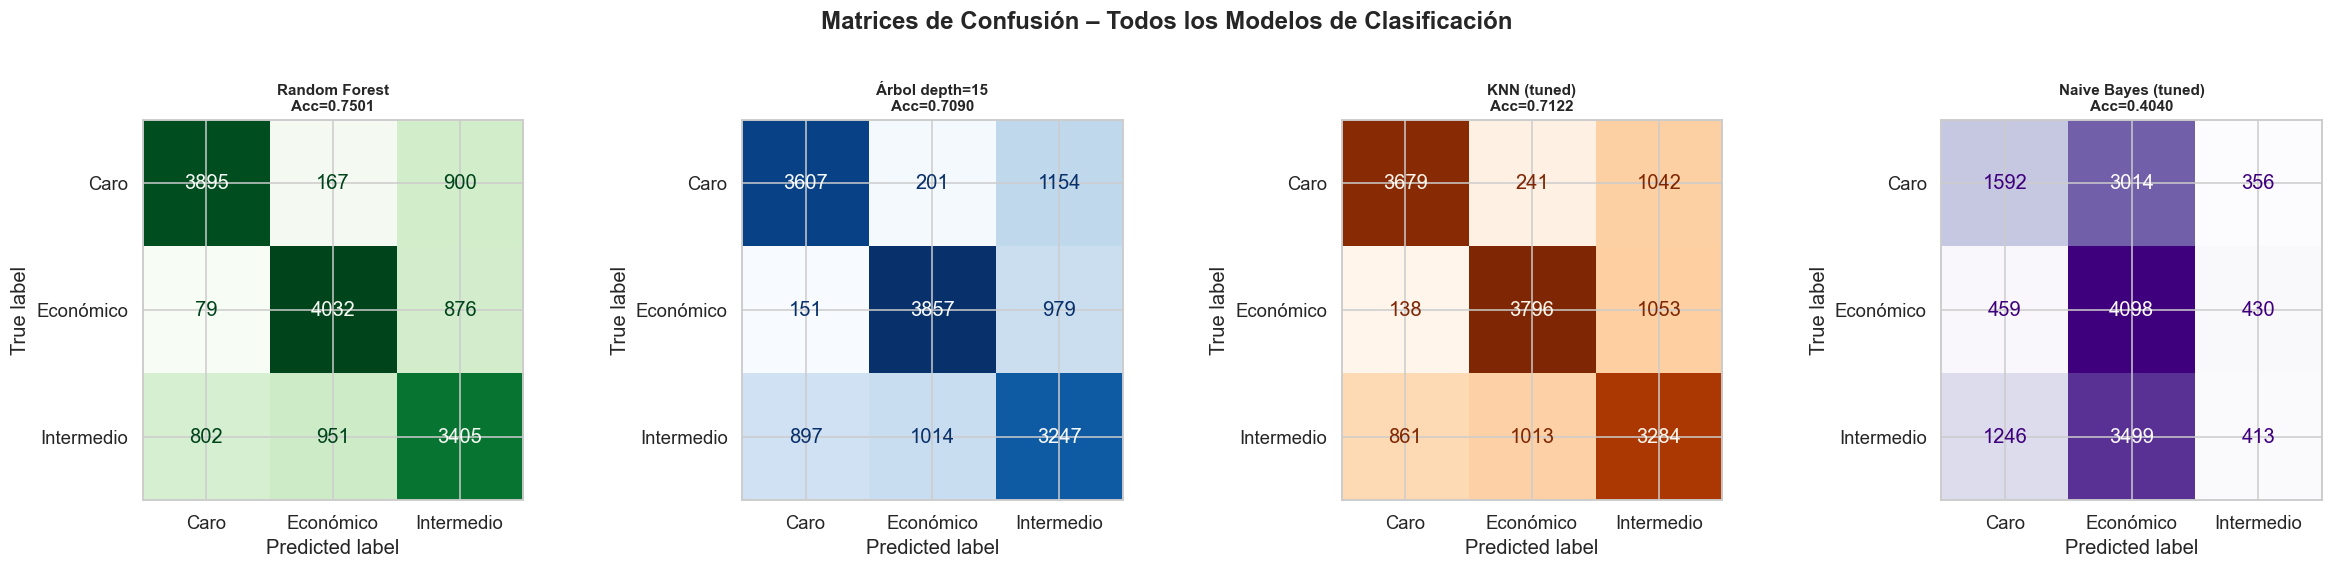

In [20]:
# Matrices de confusión comparativas 
fig, axes = plt.subplots(1,4, figsize=(22,5))
cms   = [confusion_matrix(y_test_c, yp_rf_clf),
         confusion_matrix(y_test_c, yp_tree_clf),
         confusion_matrix(y_test_c, yp_knn_clf_best),
         confusion_matrix(y_test_c, yp_nb_clf)]
titls = ['Random Forest','Árbol depth=15','KNN (tuned)','Naive Bayes (tuned)']
cmaps = ['Greens','Blues','Oranges','Purples']
for ax, cm_i, tit, cmap in zip(axes, cms, titls, cmaps):
    ConfusionMatrixDisplay(confusion_matrix=cm_i, display_labels=le.classes_).plot(ax=ax, cmap=cmap, colorbar=False)
    acc_i = np.trace(cm_i)/cm_i.sum()
    ax.set_title(f'{tit}\nAcc={acc_i:.4f}', fontweight='bold', fontsize=10)
plt.suptitle('Matrices de Confusión – Todos los Modelos de Clasificación', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
